In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
data = pd.read_csv('4110008001_databaseLoadingData.csv')
data.head()

,REF_DATE,GEO,DGUID,Indigenous identity,Age group,Gender,Overall health,Housing - Needs repairs,Persons per room (crowding),Statistics,...,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2022,Canada,2021A000011124,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",One person or fewer per room,Number of persons,...,249,units,0,v1602021051,1.2.2.2.2.1.2.1,24480.0,NaN,NaN,NaN,0
1,2022,Canada,2021A000011124,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",One person or fewer per room,Percent,...,239,units,0,v1602021052,1.2.2.2.2.1.2.2,90.2,NaN,NaN,NaN,1
2,2022,Canada,2021A000011124,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",One person or fewer per room,Low 95% confidence interval,...,239,units,0,v1602021053,1.2.2.2.2.1.2.3,86.0,NaN,NaN,NaN,1
3,2022,Canada,2021A000011124,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",One person or fewer per room,High 95% confidence interval,...,239,units,0,v1602021054,1.2.2.2.2.1.2.4,93.3,NaN,NaN,NaN,1
4,2022,Canada,2021A000011124,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",More than one but less than 1.5 persons per room,Number of persons,...,249,units,0,v1602021055,1.2.2.2.2.1.3.1,NaN,F,NaN,NaN,0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   REF_DATE                     9216 non-null   int64  
 1   GEO                          9216 non-null   object 
 2   DGUID                        9216 non-null   object 
 3   Indigenous identity          9216 non-null   object 
 4   Age group                    9216 non-null   object 
 5   Gender                       9216 non-null   object 
 6   Overall health               9216 non-null   object 
 7   Housing - Needs repairs      9216 non-null   object 
 8   Persons per room (crowding)  9216 non-null   object 
 9   Statistics                   9216 non-null   object 
 10  UOM                          9216 non-null   object 
 11  UOM_ID                       9216 non-null   int64  
 12  SCALAR_FACTOR                9216 non-null   object 
 13  SCALAR_ID         

In [33]:
data.shape

(9216, 21)

In [34]:
data.count()

REF_DATE                       9216
GEO                            9216
DGUID                          9216
Indigenous identity            9216
Age group                      9216
Gender                         9216
Overall health                 9216
Housing - Needs repairs        9216
Persons per room (crowding)    9216
Statistics                     9216
UOM                            9216
UOM_ID                         9216
SCALAR_FACTOR                  9216
SCALAR_ID                      9216
VECTOR                         9216
COORDINATE                     9216
VALUE                          2233
STATUS                         7373
SYMBOL                            0
TERMINATED                        0
DECIMALS                       9216
dtype: int64

<Axes: >

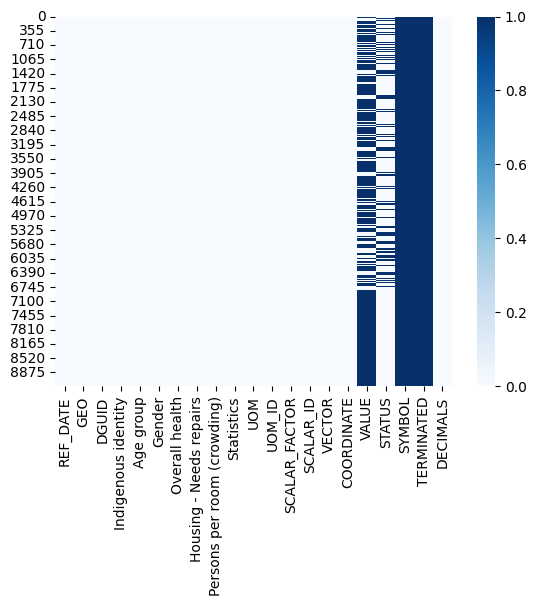

In [35]:
sns.heatmap(data.isna(), cmap='Blues')

In [36]:
# F means they are too unreliable to be published
data.loc[data['VALUE'].isnull(),:]['STATUS'].value_counts()

STATUS
F    6983
Name: count, dtype: int64

In [37]:
data = data.drop(["TERMINATED", "SYMBOL", "DECIMALS", "SCALAR_ID", "SCALAR_FACTOR", "DGUID", "GEO", "REF_DATE"], axis=1)

In [38]:
data = data.loc[data['Statistics'] == "Number of persons", :]

In [39]:
data = data.loc[data['Indigenous identity'] != "Indigenous responses not included elsewhere"]

In [40]:
data.head()

,Indigenous identity,Age group,Gender,Overall health,Housing - Needs repairs,Persons per room (crowding),Statistics,UOM,UOM_ID,VECTOR,COORDINATE,VALUE,STATUS
0,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",One person or fewer per room,Number of persons,Persons,249,v1602021051,1.2.2.2.2.1.2.1,24480.0,NaN
4,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",More than one but less than 1.5 persons per room,Number of persons,Persons,249,v1602021055,1.2.2.2.2.1.3.1,NaN,F
8,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","Total, housing - Needs repairs",1.5 persons or more per room,Number of persons,Persons,249,v1602021059,1.2.2.2.2.1.4.1,NaN,F
12,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","No, only regular maintenance is needed",One person or fewer per room,Number of persons,Persons,249,v1602021071,1.2.2.2.2.2.2.1,17730.0,NaN
16,First Nations (North American Indian),15 to 24 years,Men+,"Self-perceived general health, excellent or ve...","No, only regular maintenance is needed",More than one but less than 1.5 persons per room,Number of persons,Persons,249,v1602021075,1.2.2.2.2.2.3.1,NaN,F


In [41]:
filter = data['STATUS'].str.startswith('E', na=False)

df = data.loc[filter, ['COORDINATE', 'VALUE']].copy()

# extract prefix and last index
df[['prefix','idx']] = df['COORDINATE'].str.extract(
    r'(?P<prefix>(?:[0-9]+\.){7})(?P<idx>[0-9])'
)

df['idx'] = df['idx'].astype(int)

# pivot so we get columns 1,2,3,4
wide = df.pivot(index='prefix', columns='idx', values='VALUE')

wide = wide.reindex(columns=[1,2,3,4], fill_value=0)

wide.head()



idx,1,2,3,4
prefix,,,,
1.2.2.2.12.3.2.,3810.0,0,0,0
1.2.2.2.13.3.2.,4550.0,0,0,0
1.2.2.2.2.3.2.,5200.0,0,0,0
1.2.2.2.5.3.2.,4710.0,0,0,0
1.2.2.2.6.2.2.,3570.0,0,0,0


In [42]:


# apply condition: a[X.3] <= a[X.2] <= a[X.4]
mask = (wide[3] <= wide[2]) & (wide[2] <= wide[4])

# return X.1 coordinates
result = (wide.loc[mask]
          .index
          .to_series()
          .str.cat(['1'] * mask.sum()))


In [43]:
data['STATUS'].value_counts()

STATUS
F    1400
E     146
Name: count, dtype: int64

In [44]:
# data['REF_DATE'].value_counts()
# only data is present for 2022 year

In [45]:
# data['GEO'].value_counts()
# only data present for Indigenous population in Canada

In [46]:
data['Indigenous identity'].value_counts()

Indigenous identity
First Nations (North American Indian)    576
Métis                                    576
Inuk (Inuit)                             576
Name: count, dtype: int64

In [47]:
data['Statistics'].value_counts()

Statistics
Number of persons    1728
Name: count, dtype: int64

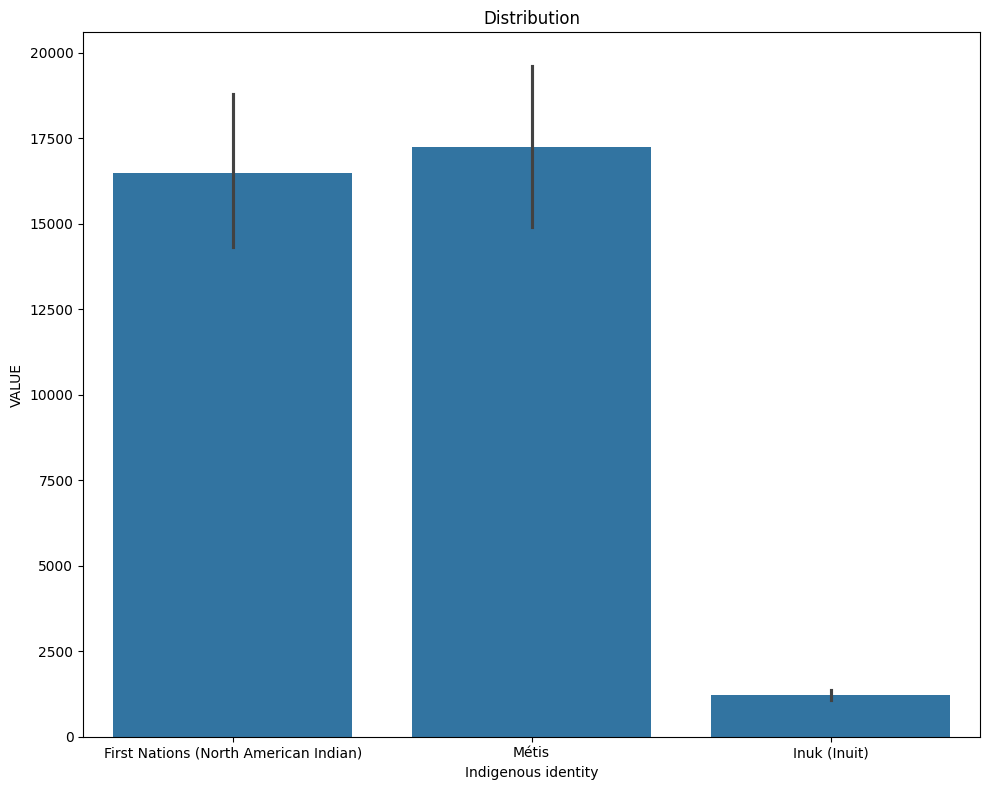

In [54]:
plt.figure(figsize=(10, 8))
sns.barplot(data, x="Indigenous identity", y="VALUE")
plt.title("Distribution")
plt.tight_layout()
plt.show()

<Axes: xlabel='Indigenous identity', ylabel='VALUE'>

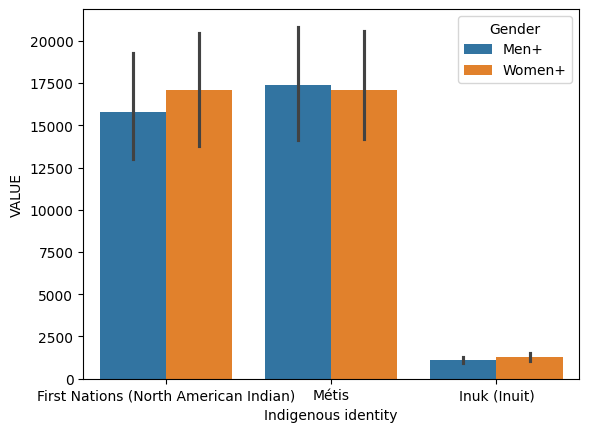

In [49]:
sns.barplot(data, x="Indigenous identity", y="VALUE", hue="Gender")

<Axes: xlabel='Indigenous identity', ylabel='VALUE'>

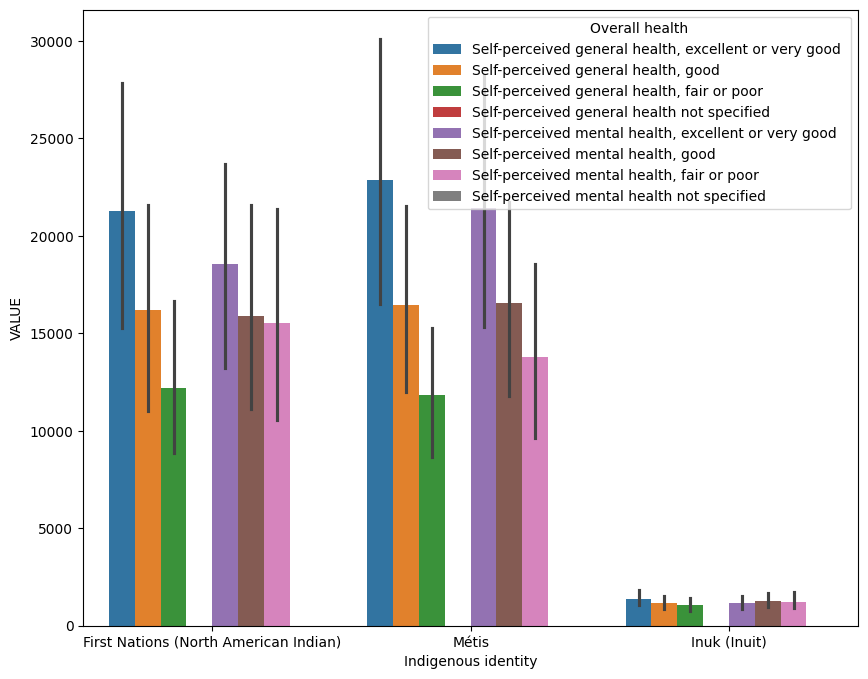

In [50]:
plt.figure(figsize=(10, 8))
sns.barplot(data, x="Indigenous identity", y="VALUE", hue="Overall health")

<Axes: xlabel='Indigenous identity', ylabel='VALUE'>

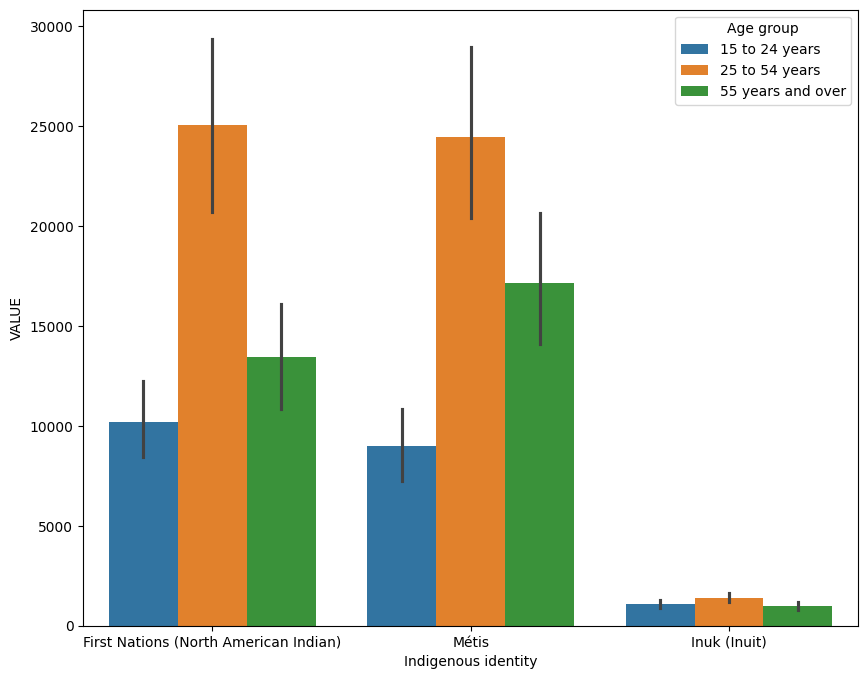

In [51]:
plt.figure(figsize=(10, 8))
sns.barplot(data, x="Indigenous identity", y="VALUE", hue="Age group")

<Axes: xlabel='Indigenous identity', ylabel='VALUE'>

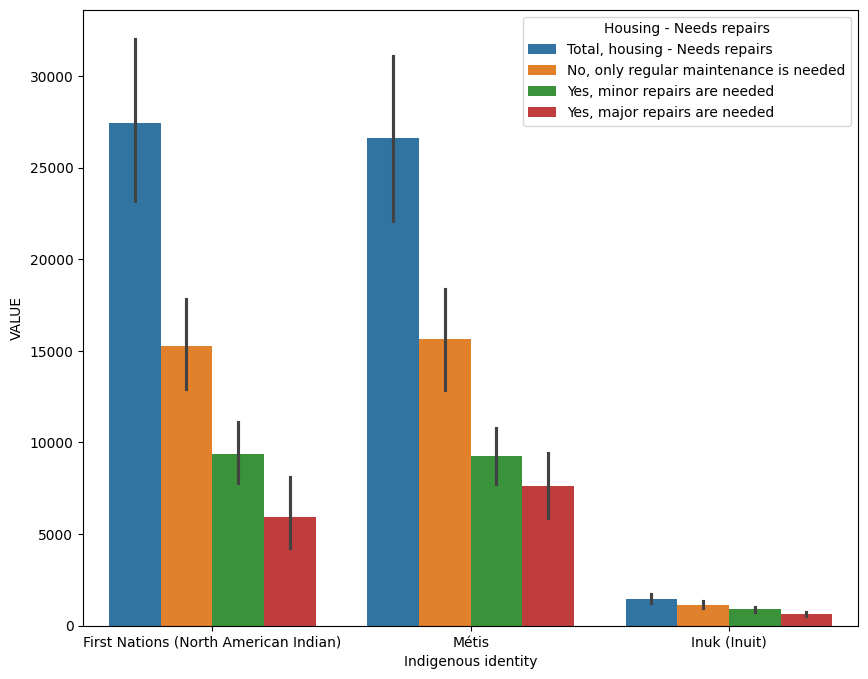

In [52]:
plt.figure(figsize=(10, 8))
sns.barplot(data, x="Indigenous identity", y="VALUE", hue="Housing - Needs repairs")

<Axes: xlabel='Indigenous identity', ylabel='VALUE'>

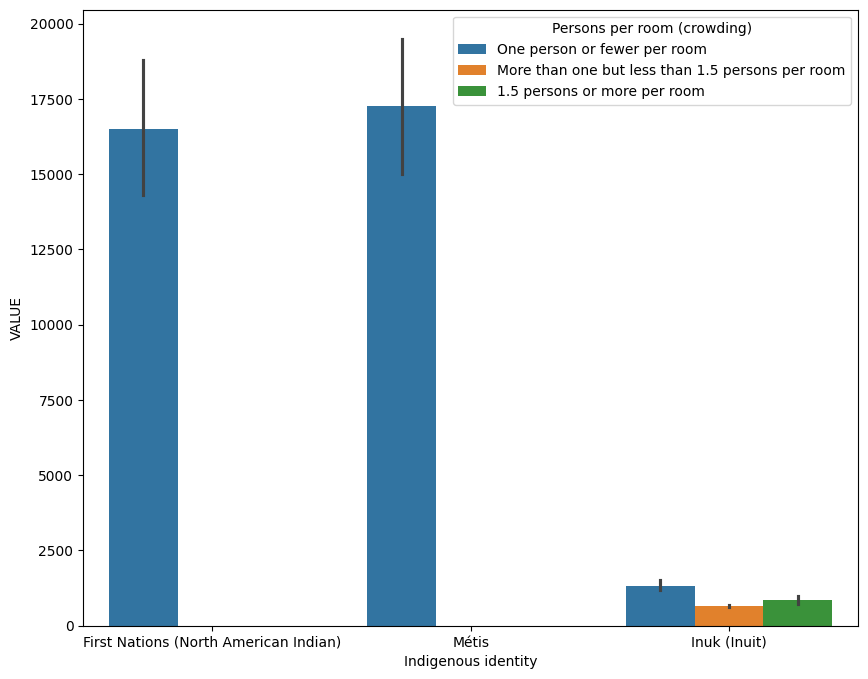

In [53]:
plt.figure(figsize=(10, 8))
sns.barplot(data, x="Indigenous identity", y="VALUE", hue="Persons per room (crowding)")